In [1]:
import pandas as pd
import os

folder_path = r"D:\Assesment\dissertation"

files = [f for f in os.listdir(folder_path) if f.endswith(".csv") and "SUB_ICB_LOCATION_CSV" in f]

appointment_dfs = []
for file in files:
    df = pd.read_csv(os.path.join(folder_path, file))
    df["source_file"] = file  # Track which file each row came from
    appointment_dfs.append(df)

#Combine all DataFrames
appointments_merged = pd.concat(appointment_dfs, ignore_index=True)
print(f"Merged {len(files)} files. Total rows: {len(appointments_merged)}")

# Rename columns for clarity
appointments_merged.rename(columns={
    "SUB_ICB_LOCATION_CODE": "sub_icb_code",
    "SUB_ICB_LOCATION_ONS_CODE": "sub_icb_ons_code",
    "SUB_ICB_LOCATION_NAME": "sub_icb_name",
    "ICB_ONS_CODE": "icb_ons_code",
    "REGION_ONS_CODE": "region_ons_code",
    "Appointment_Date": "appt_date",
    "APPT_STATUS": "appt_status",
    "HCP_TYPE": "hcp_type",
    "APPT_MODE": "appt_mode",
    "TIME_BETWEEN_BOOK_AND_APPT": "time_between",
    "COUNT_OF_APPOINTMENTS": "appt_count"
}, inplace=True)

# Drop rows with missing data
appointments_cleaned = appointments_merged.dropna()

# Save the cleaned merged data to CSV
output_path = os.path.join(folder_path, "merged_cleaned_appointments.csv")
appointments_cleaned.to_csv(output_path, index=False)

print(f"Cleaned data saved to: {output_path}")


Merged 30 files. Total rows: 9305337
Cleaned data saved to: D:\Assesment\dissertation\merged_cleaned_appointments.csv


In [2]:
import pandas as pd
import os

# Step 1: List the uploaded CSV files (update the list if needed)
weather_files = [
    "London, England, United K... 2021-01-01 to 2021-12-31.csv",
    "London, England, United K... 2022-01-01 to 2022-12-31.csv",
    "London, England, United K... 2023-01-01 to 2023-12-31.csv",
    "London, England, United K... 2024-01-01 to 2024-12-31.csv"
]

# Step 2: Load and merge all weather files
weather_dfs = []
for file in weather_files:
    df = pd.read_csv(file)
    df["source_file"] = file  # optional: to track the source
    weather_dfs.append(df)

# Step 3: Combine all into one DataFrame
weather_merged = pd.concat(weather_dfs, ignore_index=True)

# Step 4: Drop rows without valid datetime
weather_merged = weather_merged.dropna(subset=["datetime"])

# Step 5: Convert datetime column to proper date format (optional, helps with merging)
weather_merged["datetime"] = pd.to_datetime(weather_merged["datetime"]).dt.date

# Step 6: Save the merged DataFrame as a new CSV
weather_merged.to_csv("merged_cleaned_weather.csv", index=False)

print("Merged weather data saved as 'merged_cleaned_weather.csv'")


Merged weather data saved as 'merged_cleaned_weather.csv'


In [3]:
import pandas as pd

# Set path where your files are stored
path = "D:/Assesment/dissertation"

# Load the datasets
appt_df = pd.read_csv(f"{path}/merged_cleaned_appointments.csv")
weather_df = pd.read_csv("merged_cleaned_weather.csv")

# Show head and tail
print("Appointments - Head")
print(appt_df.head())

print("\nAppointments - Tail")
print(appt_df.tail())

print("\nWeather - Head")
print(weather_df.head())

print("\n Weather - Tail")
print(weather_df.tail())


Appointments - Head
  sub_icb_code sub_icb_ons_code                                sub_icb_name  \
0          00L        E38000130  NHS North East and North Cumbria ICB - 00L   
1          00L        E38000130  NHS North East and North Cumbria ICB - 00L   
2          00L        E38000130  NHS North East and North Cumbria ICB - 00L   
3          00L        E38000130  NHS North East and North Cumbria ICB - 00L   
4          00L        E38000130  NHS North East and North Cumbria ICB - 00L   

  icb_ons_code region_ons_code  appt_date appt_status              hcp_type  \
0    E54000050       E40000012  01APR2023         DNA  Other Practice staff   
1    E54000050       E40000012  01APR2023    Attended               Unknown   
2    E54000050       E40000012  01APR2023    Attended  Other Practice staff   
3    E54000050       E40000012  01APR2023    Attended                    GP   
4    E54000050       E40000012  01APR2023    Attended                    GP   

      appt_mode       time_bet

In [4]:
import pandas as pd

# Filter for London regions
london_codes = ["E40000003", "E40000007"]
appt_df_london = appt_df[appt_df["region_ons_code"].isin(london_codes)].copy()

# Convert date formats
appt_df_london["appt_date_formatted"] = pd.to_datetime(appt_df_london["appt_date"], format="%d%b%Y", errors='coerce')
weather_df["weather_date"] = pd.to_datetime(weather_df["datetime"], errors='coerce')

# Merge on date
merged_df = pd.merge(
    appt_df_london,
    weather_df,
    left_on="appt_date_formatted",
    right_on="weather_date",
    how="left"
)

# Save merged dataset
merged_df.to_csv("merged_london_appointments_weather.csv", index=False)
print("Merged dataset created with shape:", merged_df.shape)


Merged dataset created with shape: (1771609, 48)


In [5]:
# Convert 'appt_date' into proper datetime if not already
merged_df["appt_date_formatted"] = pd.to_datetime(merged_df["appt_date"], format="%d%b%Y", errors="coerce")

# Create 'day_of_week' column
merged_df["day_of_week"] = merged_df["appt_date_formatted"].dt.day_name()


In [6]:
# Create binary label: 1 = Attended, 0 = DNA
merged_df = merged_df[merged_df["appt_status"].isin(["Attended", "DNA"])].copy()
merged_df["label"] = merged_df["appt_status"].apply(lambda x: 1 if x == "Attended" else 0)

# Add day of the week
merged_df["day_of_week"] = merged_df["appt_date_formatted"].dt.day_name()

# Interaction feature
merged_df["mode_time"] = merged_df["appt_mode"] + "_" + merged_df["time_between"]

# Save cleaned data for modeling
merged_df.to_csv("cleaned_merged_model_data.csv", index=False)
print("Data prepared for modeling. Rows:", merged_df.shape[0])


Data prepared for modeling. Rows: 1186775


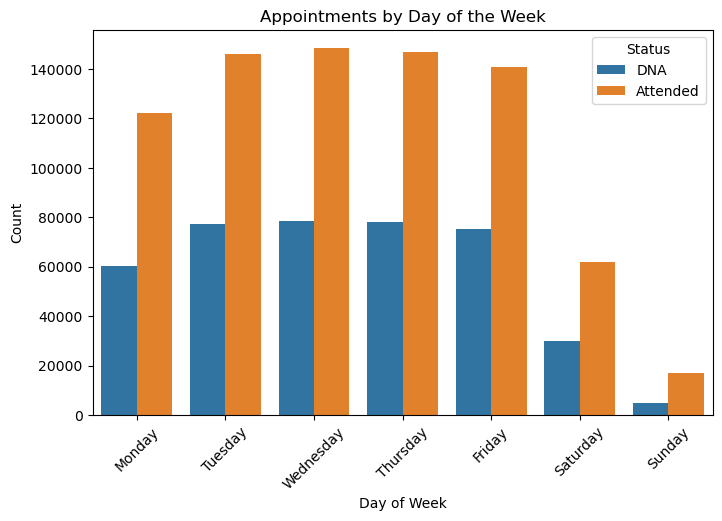

In [7]:
# Appointments by Day of Week
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(
    data=merged_df, 
    x="day_of_week", 
    hue="appt_status", 
    order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)
plt.title("Appointments by Day of the Week")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Status")
plt.show()


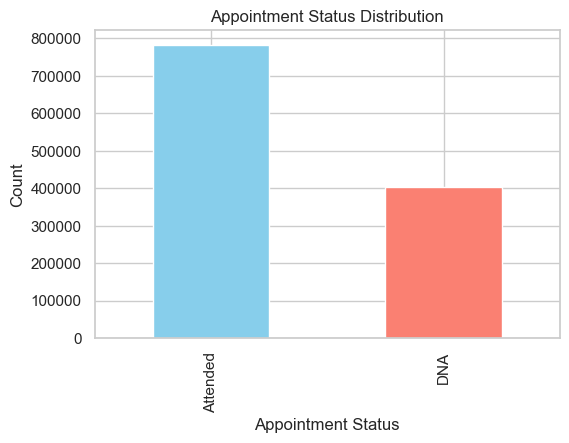

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# 1. Appointment Status Distribution
plt.figure(figsize=(6, 4))
merged_df["appt_status"].value_counts().plot(kind="bar", color=["skyblue", "salmon"])
plt.title("Appointment Status Distribution")
plt.xlabel("Appointment Status")
plt.ylabel("Count")
plt.show()

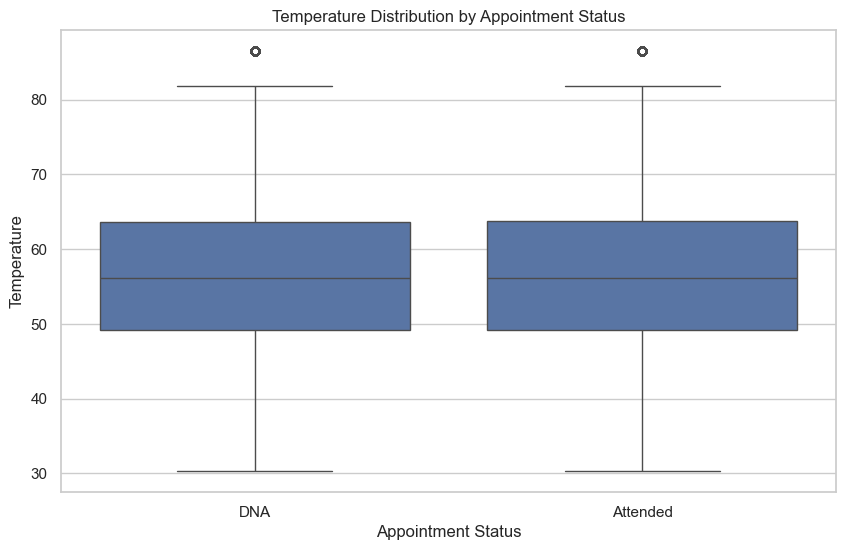

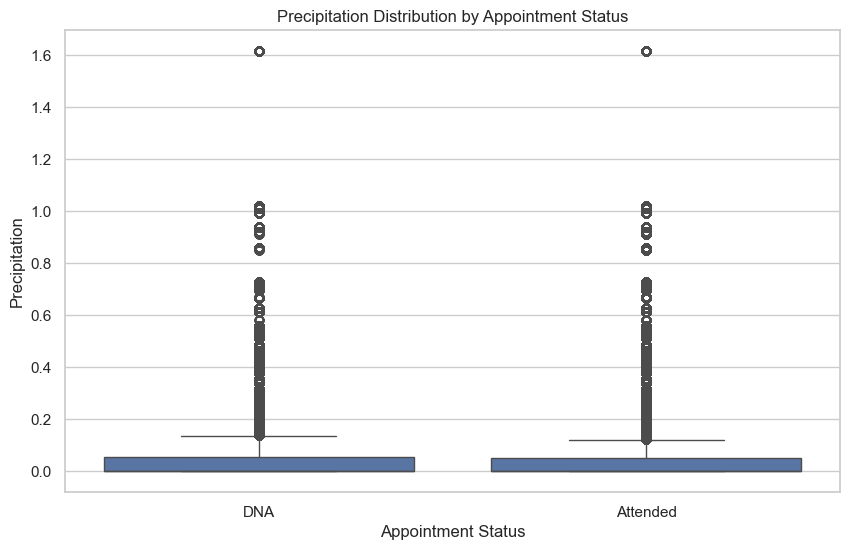

In [9]:
# 3. Weather Effect: Temperature and Precipitation
plt.figure(figsize=(10, 6))
sns.boxplot(data=merged_df, x="appt_status", y="temp")
plt.title("Temperature Distribution by Appointment Status")
plt.xlabel("Appointment Status")
plt.ylabel("Temperature")
plt.show()


plt.figure(figsize=(10, 6))
sns.boxplot(data=merged_df, x="appt_status", y="precip")
plt.title("Precipitation Distribution by Appointment Status")
plt.xlabel("Appointment Status")
plt.ylabel("Precipitation")
plt.show()

C:\Users\emadn\AppData\Local\Temp\ipykernel_11268\2730486403.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mode_dna, x="appt_mode", y="DNA_rate", palette="coolwarm")


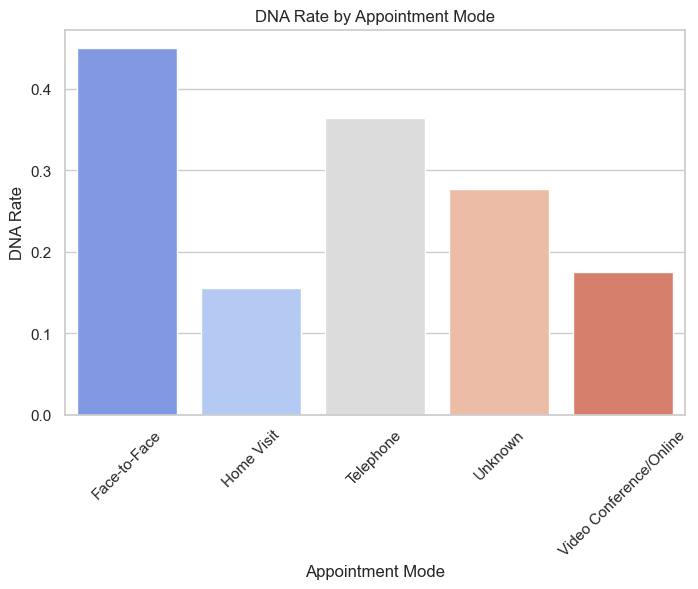

In [10]:
# 4. Appointment Mode vs DNA Rate
mode_dna = merged_df.groupby("appt_mode")["label"].mean().reset_index()
mode_dna["DNA_rate"] = 1 - mode_dna["label"]

plt.figure(figsize=(8, 5))
sns.barplot(data=mode_dna, x="appt_mode", y="DNA_rate", palette="coolwarm")
plt.title("DNA Rate by Appointment Mode")
plt.xlabel("Appointment Mode")
plt.ylabel("DNA Rate")
plt.xticks(rotation=45)
plt.show()


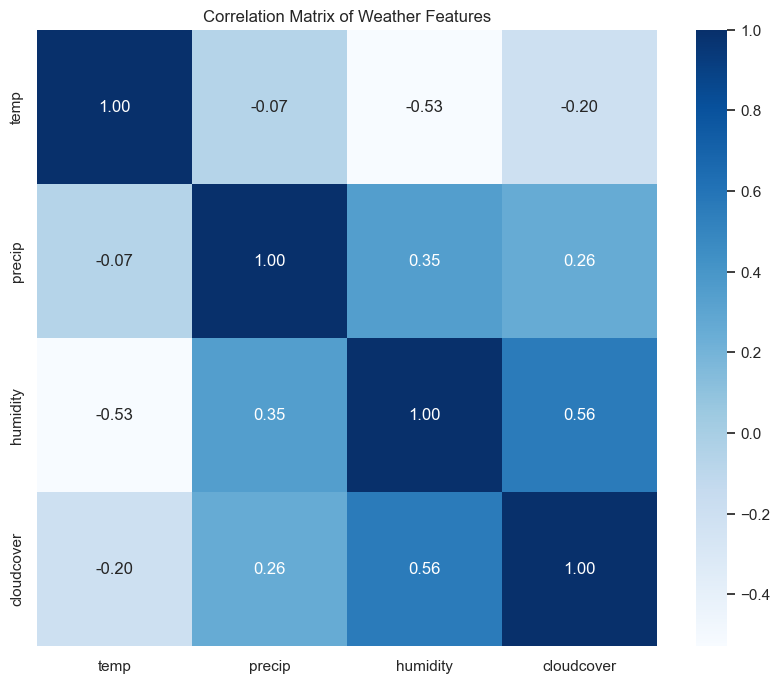

In [11]:
# 5. Correlation Matrix for Numerical Features
plt.figure(figsize=(10, 8))
num_cols = ["temp", "precip", "humidity", "cloudcover"]
sns.heatmap(merged_df[num_cols].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Matrix of Weather Features")
plt.show()


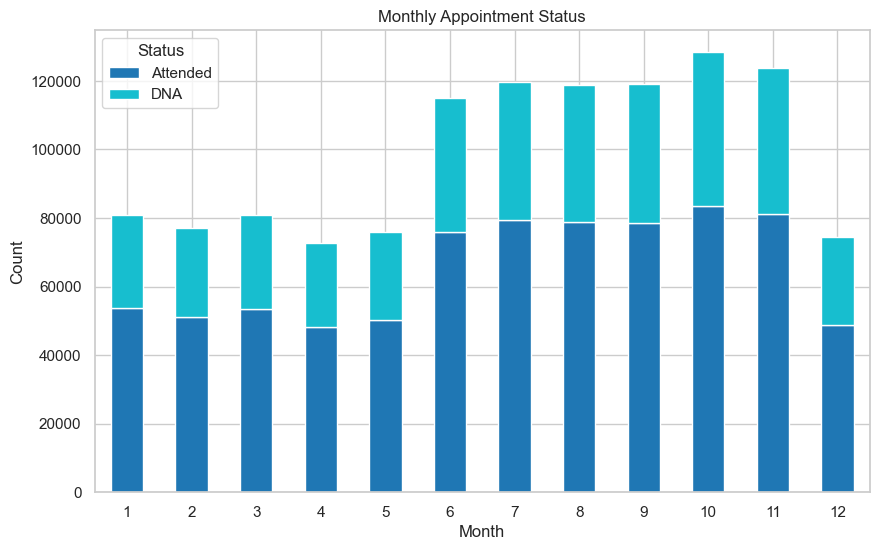

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Monthly trend of appointments
merged_df["month"] = merged_df["appt_date_formatted"].dt.month
monthly_counts = merged_df.groupby(["month", "appt_status"]).size().unstack(fill_value=0)

monthly_counts.plot(kind="bar", stacked=True, figsize=(10,6), colormap="tab10")
plt.title("Monthly Appointment Status")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Status")
plt.show()


C:\Users\emadn\AppData\Local\Temp\ipykernel_11268\2205309090.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dna_rate = merged_df.groupby("day_of_week").apply(
C:\Users\emadn\AppData\Local\Temp\ipykernel_11268\2205309090.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dna_rate, x="day_of_week", y="DNA Rate (%)", palette="viridis")


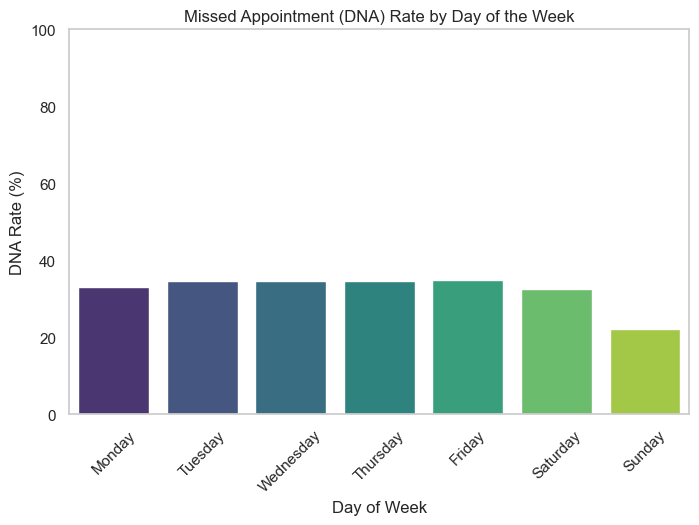

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Prepare the day_of_week again if needed
merged_df["appt_date_formatted"] = pd.to_datetime(merged_df["appt_date"], format="%d%b%Y", errors="coerce")
merged_df["day_of_week"] = merged_df["appt_date_formatted"].dt.day_name()

#Group by day_of_week and calculate DNA rate
dna_rate = merged_df.groupby("day_of_week").apply(
    lambda x: (x["appt_status"].value_counts(normalize=True).get("DNA", 0)) * 100
).reset_index(name="DNA Rate (%)")

#Order the days correctly
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dna_rate["day_of_week"] = pd.Categorical(dna_rate["day_of_week"], categories=day_order, ordered=True)
dna_rate = dna_rate.sort_values("day_of_week")

#Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=dna_rate, x="day_of_week", y="DNA Rate (%)", palette="viridis")
plt.title("Missed Appointment (DNA) Rate by Day of the Week")
plt.xlabel("Day of Week")
plt.ylabel("DNA Rate (%)")
plt.xticks(rotation=45)
plt.ylim(0, 100)  # Because it's a percentage
plt.grid(axis='y')
plt.show()


C:\Users\emadn\AppData\Local\Temp\ipykernel_11268\3885940410.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weather_dna = merged_df.groupby("conditions").apply(
C:\Users\emadn\AppData\Local\Temp\ipykernel_11268\3885940410.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weather_dna_top, x="DNA Rate (%)", y="conditions", palette="magma")


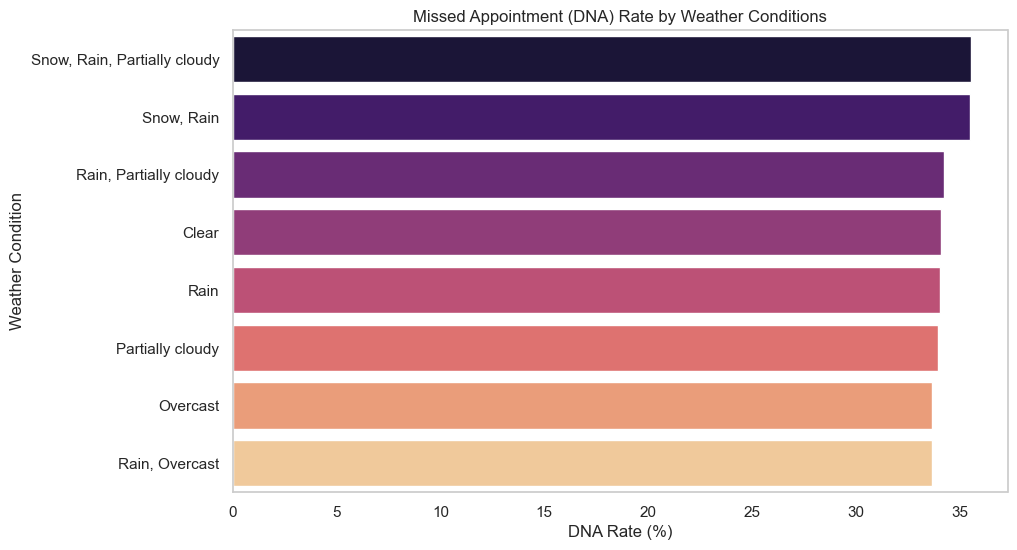

In [14]:
#  Group by conditions and calculate DNA rate
weather_dna = merged_df.groupby("conditions").apply(
    lambda x: (x["appt_status"].value_counts(normalize=True).get("DNA", 0)) * 100
).reset_index(name="DNA Rate (%)")

# Take top 8 most frequent conditions (to avoid overcrowded chart)
top_conditions = merged_df["conditions"].value_counts().head(8).index
weather_dna_top = weather_dna[weather_dna["conditions"].isin(top_conditions)]

# Sort properly for a better chart
weather_dna_top = weather_dna_top.sort_values("DNA Rate (%)", ascending=False)

#  Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=weather_dna_top, x="DNA Rate (%)", y="conditions", palette="magma")
plt.title("Missed Appointment (DNA) Rate by Weather Conditions")
plt.xlabel("DNA Rate (%)")
plt.ylabel("Weather Condition")
plt.grid(axis='x')
plt.show()


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#  Filter out essential columns
features = ["appt_mode", "hcp_type", "time_between", "temp", "precip", "humidity", "cloudcover"]
target = "appt_status"

# Convert appt_status to binary
merged_df["label"] = merged_df["appt_status"].apply(lambda x: 1 if x == "Attended" else 0)

# Split physical and virtual modes
physical_modes = ["Face-to-Face", "Home Visit"]
virtual_modes = ["Telephone", "Video Conference/Online"]

phys_df = merged_df[merged_df["appt_mode"].isin(physical_modes)].copy()
virt_df = merged_df[merged_df["appt_mode"].isin(virtual_modes)].copy()

# Define categorical and numeric columns
cat_features = ["appt_mode", "hcp_type", "time_between"]
num_features = ["temp", "precip", "humidity", "cloudcover"]

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
], remainder="passthrough")

# Modeling function
def train_and_evaluate(df, segment="Segment"):
    X = df[features]
    y = df["label"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
    
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    print(f"\n {segment} Results")
    print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall   :", round(recall_score(y_test, y_pred), 4))
    print("F1 Score :", round(f1_score(y_test, y_pred), 4))

# Train & evaluate both
train_and_evaluate(phys_df, "Physical Appointments")
train_and_evaluate(virt_df, "Virtual Appointments")



 Physical Appointments Results
Accuracy : 0.5277
Precision: 0.6004
Recall   : 0.6855
F1 Score : 0.6402

 Virtual Appointments Results
Accuracy : 0.6612
Precision: 0.6847
Recall   : 0.9437
F1 Score : 0.7936


In [16]:
import pandas as pd

# Load cleaned data
df = pd.read_csv("cleaned_merged_model_data.csv")

# Separate by mode
physical_modes = ["Face-to-Face", "Home Visit"]
virtual_modes = ["Telephone", "Video Conference/Online"]

phys_df = df[df["appt_mode"].isin(physical_modes)].copy()
virt_df = df[df["appt_mode"].isin(virtual_modes)].copy()

# Features and label
features = ["appt_mode", "hcp_type", "time_between", "day_of_week", "mode_time",
            "temp", "precip", "humidity", "cloudcover"]
target = "label"


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def run_model(df, model, model_name, segment):
    cat_cols = ["appt_mode", "hcp_type", "time_between", "day_of_week", "mode_time"]
    num_cols = ["temp", "precip", "humidity", "cloudcover"]

    X = df[features]
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

    pipeline = Pipeline([
        ("preprocessor", ColumnTransformer([
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
        ], remainder="passthrough")),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print(f"\n {segment} | {model_name} Results")
    print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall   :", round(recall_score(y_test, y_pred), 4))
    print("F1 Score :", round(f1_score(y_test, y_pred), 4))


In [18]:
from sklearn.ensemble import RandomForestClassifier
run_model(phys_df, RandomForestClassifier(n_estimators=100), "Random Forest", "Physical")
run_model(virt_df, RandomForestClassifier(n_estimators=100), "Random Forest", "Virtual")



 Physical | Random Forest Results
Accuracy : 0.528
Precision: 0.6003
Recall   : 0.6871
F1 Score : 0.6408

 Virtual | Random Forest Results
Accuracy : 0.6613
Precision: 0.6847
Recall   : 0.944
F1 Score : 0.7937


In [19]:
from sklearn.ensemble import GradientBoostingClassifier
run_model(phys_df, GradientBoostingClassifier(n_estimators=100), "Gradient Boosting", "Physical")
run_model(virt_df, GradientBoostingClassifier(n_estimators=100), "Gradient Boosting", "Virtual")



 Physical | Gradient Boosting Results
Accuracy : 0.6104
Precision: 0.6313
Recall   : 0.8754
F1 Score : 0.7336

 Virtual | Gradient Boosting Results
Accuracy : 0.6902
Precision: 0.6902
Recall   : 1.0
F1 Score : 0.8167


In [20]:
from sklearn.tree import DecisionTreeClassifier
run_model(phys_df, DecisionTreeClassifier(), "Decision Tree", "Physical")
run_model(virt_df, DecisionTreeClassifier(), "Decision Tree", "Virtual")



 Physical | Decision Tree Results
Accuracy : 0.5215
Precision: 0.6035
Recall   : 0.6389
F1 Score : 0.6207

 Virtual | Decision Tree Results
Accuracy : 0.6495
Precision: 0.6823
Recall   : 0.9212
F1 Score : 0.7839


In [21]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

nb_cat_processor = ColumnTransformer([
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_features),
    ("num", StandardScaler(), num_features)
])

def run_nb(df, name="Naive Bayes"):
    X = df[features]
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

    pipe = Pipeline([
        ("preprocess", nb_cat_processor),
        ("clf", GaussianNB())
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    print(f"\n {name} Results")
    print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall   :", round(recall_score(y_test, y_pred), 4))
    print("F1 Score :", round(f1_score(y_test, y_pred), 4))

run_nb(phys_df, "Naive Bayes - Physical")
run_nb(virt_df, "Naive Bayes - Virtual")



 Naive Bayes - Physical Results
Accuracy : 0.5716
Precision: 0.8121
Recall   : 0.3915
F1 Score : 0.5284

 Naive Bayes - Virtual Results
Accuracy : 0.6885
Precision: 0.6908
Recall   : 0.9933
F1 Score : 0.8149


In [22]:
from sklearn.neural_network import MLPClassifier

def run_model(df, model, model_name, segment):
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    cat_features = ["appt_mode", "hcp_type", "time_between"]
    num_features = ["temp", "precip", "humidity", "cloudcover"]
    features = cat_features + num_features

    X = df[features]
    y = df["label"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

    preprocessor = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ], remainder="passthrough")

    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("clf", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print(f"\n {model_name} | {segment} Results")
    print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall   :", round(recall_score(y_test, y_pred), 4))
    print("F1 Score :", round(f1_score(y_test, y_pred), 4))

# Run the model correctly with both name and segment
run_model(phys_df, MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=300, random_state=42), "MLP", "Physical")
run_model(virt_df, MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=300, random_state=42), "MLP", "Virtual")



 MLP | Physical Results
Accuracy : 0.6128
Precision: 0.6128
Recall   : 1.0
F1 Score : 0.7599

 MLP | Virtual Results
Accuracy : 0.6902
Precision: 0.6902
Recall   : 1.0
F1 Score : 0.8167


In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define features
features = ["appt_mode", "hcp_type", "time_between", "temp", "precip", "humidity", "cloudcover"]
cat_features = ["appt_mode", "hcp_type", "time_between"]
num_features = ["temp", "precip", "humidity", "cloudcover"]

# Split features and target
X = phys_df[features]
y = phys_df["label"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Preprocessing
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ("num", StandardScaler(), num_features)
])

#  Pipeline
pipe = Pipeline([
    ("preprocess", preprocessor),
    ("clf", MLPClassifier(max_iter=300, random_state=42))
])

# Define parameter grid
param_grid = {
    "clf__hidden_layer_sizes": [(8,), (16, 8), (32, 16)],
    "clf__activation": ["relu", "tanh"],
    "clf__alpha": [0.0001, 0.001],
    "clf__learning_rate": ["constant", "adaptive"]
}

# Grid search
grid_search = GridSearchCV(pipe, param_grid, cv=3, n_jobs=-1, scoring="f1", verbose=2)
grid_search.fit(X_train, y_train)

# Evaluate best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(" Best Hyperparameters:", grid_search.best_params_)
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))


Fitting 3 folds for each of 24 candidates, totalling 72 fits
 Best Hyperparameters: {'clf__activation': 'tanh', 'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (32, 16), 'clf__learning_rate': 'constant'}
Accuracy : 0.6119
Precision: 0.6169
Recall   : 0.9676
F1 Score : 0.7534


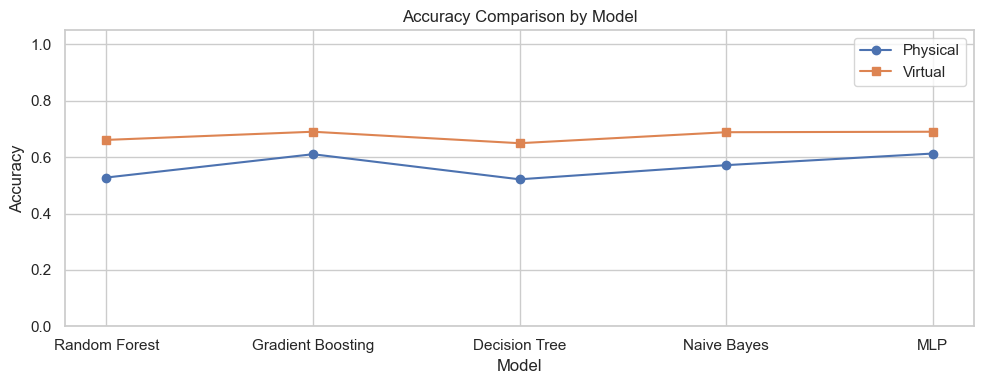

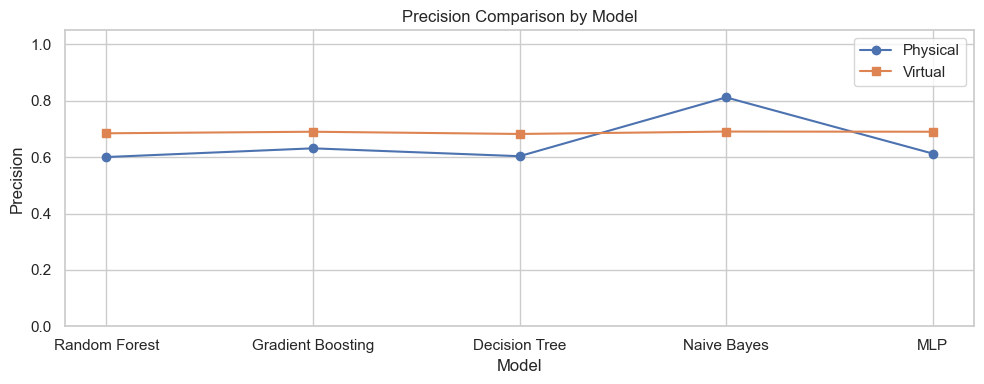

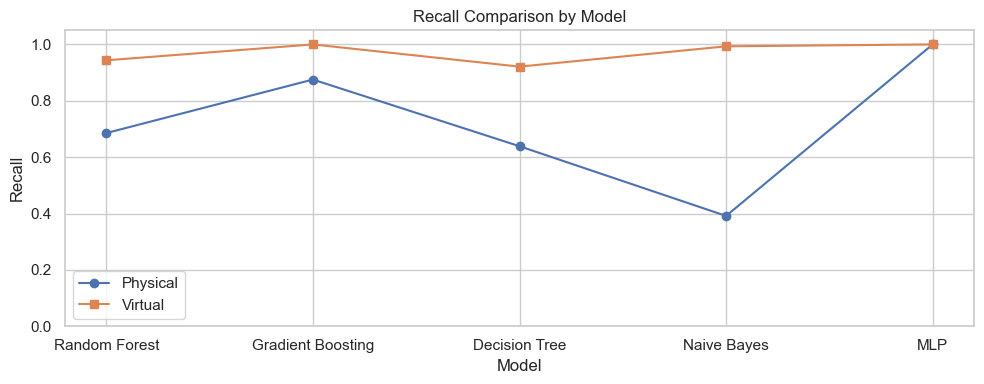

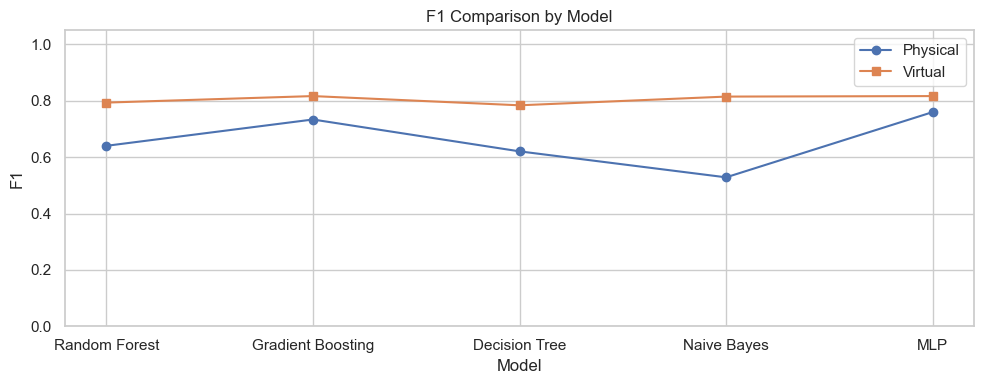

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# Model performance data
data = {
    "Model": ["Random Forest", "Gradient Boosting", "Decision Tree", "Naive Bayes", "MLP"],
    "Physical_Accuracy": [0.5277, 0.6104, 0.5214, 0.5716, 0.6128],
    "Physical_Precision": [0.6004, 0.6313, 0.6034, 0.8121, 0.6128],
    "Physical_Recall": [0.6855, 0.8754, 0.6388, 0.3915, 1.0],
    "Physical_F1": [0.6402, 0.7336, 0.6206, 0.5284, 0.7599],
    "Virtual_Accuracy": [0.6612, 0.6902, 0.6495, 0.6885, 0.6902],
    "Virtual_Precision": [0.6847, 0.6902, 0.6823, 0.6908, 0.6902],
    "Virtual_Recall": [0.9437, 1.0, 0.9212, 0.9933, 1.0],
    "Virtual_F1": [0.7936, 0.8167, 0.784, 0.8149, 0.8167]
}

df_perf = pd.DataFrame(data)

# Plotting
metrics = ["Accuracy", "Precision", "Recall", "F1"]
for metric in metrics:
    plt.figure(figsize=(10, 4))
    plt.plot(df_perf["Model"], df_perf[f"Physical_{metric}"], marker='o', label="Physical")
    plt.plot(df_perf["Model"], df_perf[f"Virtual_{metric}"], marker='s', label="Virtual")
    plt.title(f"{metric} Comparison by Model")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


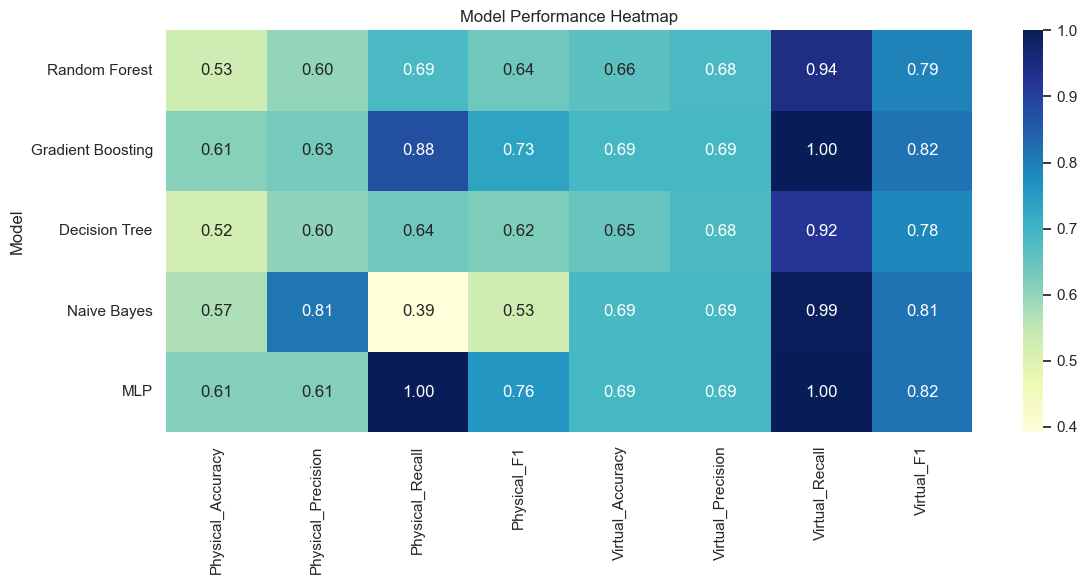

In [25]:
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.heatmap(df_perf.set_index("Model"), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Model Performance Heatmap")
plt.tight_layout()
plt.show()


In [26]:
df_perf["Avg_Physical"] = df_perf[[f"Physical_{m}" for m in metrics]].mean(axis=1)
df_perf["Avg_Virtual"] = df_perf[[f"Virtual_{m}" for m in metrics]].mean(axis=1)
df_perf[["Model", "Avg_Physical", "Avg_Virtual"]]


,Model,Avg_Physical,Avg_Virtual
0,Random Forest,0.613450,0.770800
1,Gradient Boosting,0.712675,0.799275
2,Decision Tree,0.596050,0.759250
3,Naive Bayes,0.575900,0.796875
4,MLP,0.746375,0.799275
